In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import  GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [2]:
path = r'..\Data\Original_Data\Motot_Type_YWNC-305.xlsx'
df = pd.read_excel(path)

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
mask = df["Time"].astype(str).str.contains(", 24:")

# fix time: replace 24 with 00
df.loc[mask, "Time"] = (
    df.loc[mask, "Time"]
      .str.replace(", 24:", ", 00:", n=1)
)

# Convert datetime type data
df["Time"] = pd.to_datetime(df["Time"], format="%d/%m/%Y, %H:%M:%S")

# Short by time (Important for energy data)
df = df.sort_values('Time')

# Set time as index
df = df.set_index('Time')

In [5]:
df['KWH_diff'] = df["TOTAL_NET_KWH"].diff()

## Replacing the -ve KWH_diff with nan

df['KWH_diff'] = df['KWH_diff'].where(df['KWH_diff'] >= 0)

# Drop the nan value
df = df.dropna(subset=['KWH_diff'])

In [6]:
def split_large_gaps(df, threshold=1.0):
    df = df.sort_index()

    rows_to_add = []

    # recompute gap hours EVERY iteration
    gap_hours = df.index.to_series().diff().dt.total_seconds() / 3600

    for i in range(1, len(df)):
        gap = gap_hours.iloc[i]

        if gap > threshold:
            prev_time = df.index[i - 1]
            curr_time = df.index[i]

            midpoint = prev_time + (curr_time - prev_time) / 2

            energy = df.iloc[i]['KWH_diff'] / 2

            # halve current row energy
            df.at[curr_time, 'KWH_diff'] = energy

            # create midpoint row
            new_row = df.loc[curr_time].copy()
            new_row.name = midpoint
            new_row['KWH_diff'] = energy

            # invalidate non-energy features
            for col in ['AVG_CURRENT', 'AVG_V_LL', 'AVG_V_LN', 'FREQUENCY']:
                if col in new_row:
                    new_row[col] = np.nan

            rows_to_add.append(new_row)

    if not rows_to_add:
        return df, False

    df = pd.concat([df, pd.DataFrame(rows_to_add)]).sort_index()

    return df, True

In [7]:
while True:
    df, changed = split_large_gaps(df, threshold=1.0)
    if not changed:
        break

In [8]:
## Resampling of data

hourly_df = (
    df
    .resample('1H')
    .agg({
        'KWH_diff': 'sum',
        'AVG_CURRENT': 'mean',
        'AVG_V_LN': 'mean'
    })
)

C:\Users\devan\AppData\Local\Temp\ipykernel_2468\2690796910.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


In [9]:
hourly_df.rename(columns={'KWH_diff': 'HOURLY_KWH'}, inplace=True)
hourly_df['HOURLY_KWH'] = hourly_df['HOURLY_KWH'].replace(0.0, np.nan)

In [10]:
cols = ['AVG_CURRENT', 'AVG_V_LN']

for col in cols:
    hourly_df[col] = hourly_df[col].fillna(hourly_df[col].median())

In [11]:
# Adding a gap flag

hourly_df['long_gap_flag'] = hourly_df['AVG_CURRENT'].isna() & hourly_df['AVG_V_LN'].isna()

# Adding day, hour and weekday
hourly_df['hour'] = hourly_df.index.hour
hourly_df['day'] = hourly_df.index.day
hourly_df['weekday'] = hourly_df.index.weekday

# Convert hour & weekday to sine–cosine
hourly_df["hour_sin"] = np.sin(2 * np.pi * hourly_df["hour"] / 24)
hourly_df["hour_cos"] = np.cos(2 * np.pi * hourly_df["hour"] / 24)
hourly_df["weekday_sin"] = np.sin(2 * np.pi * hourly_df["weekday"] / 7)
hourly_df["weekday_cos"] = np.cos(2 * np.pi * hourly_df["weekday"] / 7)

# Lag Features (MOST IMPORTANT for Time Series)
for lag in [1, 8, 24, 168]:
    hourly_df[f"kwh_lag_{lag}"] = hourly_df["HOURLY_KWH"].shift(lag)
    
# Add shift time feature 7 to 15 hrs.
hourly_df["is_7to15_shift"] = (
    (hourly_df["hour"] >= 7) & (hourly_df["hour"] < 15)
).astype(int)

# Rolling Statistics (Smooths Noise)
hourly_df["kwh_roll_2"] = hourly_df["HOURLY_KWH"].rolling(2).mean()
hourly_df["kwh_roll_24"] = hourly_df["HOURLY_KWH"].rolling(24).mean()

# Interaction Features (Energy ≠ single variable)
hourly_df["power_proxy"] = hourly_df["AVG_CURRENT"] * hourly_df["AVG_V_LN"]

# Time since last valid reading
gap_id = hourly_df["long_gap_flag"].cumsum()
hourly_df["time_since_gap"] = (
    hourly_df
    .groupby(gap_id)
    .cumcount()
)
hourly_df["time_since_gap_log"] = np.log1p(hourly_df["time_since_gap"])

# Is weekend
hourly_df["is_sunday"] = (hourly_df["weekday"] == 6).astype(int)

# Low-usage
rolling_baseline = hourly_df["HOURLY_KWH"].rolling(
    window=24,
    min_periods=12
).mean()
hourly_df["low_activity_detected"] = (
    hourly_df["HOURLY_KWH"] < 0.25 * rolling_baseline
).astype(int)

#  Spike Detection
rolling_median = hourly_df["HOURLY_KWH"].rolling(
    window=24,
    min_periods=12
).median()
mad = (
    (hourly_df["HOURLY_KWH"] - rolling_median)
    .abs()
    .rolling(24, min_periods=12)
    .median()
)
hourly_df["spike_detected"] = (
    hourly_df["HOURLY_KWH"] > (rolling_median + 3 * mad)
).astype(int)



In [12]:
# Handeling Outliers
Q1 = hourly_df['HOURLY_KWH'].quantile(0.25)
Q3 = hourly_df['HOURLY_KWH'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

hourly_df['HOURLY_KWH_capped'] = hourly_df['HOURLY_KWH'].clip(lower=lower_limit, upper=upper_limit)

In [13]:
# Important features
rf_feature_cols = ["AVG_CURRENT", "AVG_V_LN", "power_proxy", "hour", "weekday", "hour_sin", "hour_cos", "weekday_sin", 
                   "weekday_cos", "kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168", "kwh_roll_2", "kwh_roll_24", 
                   "is_7to15_shift", "is_sunday", "time_since_gap", "low_activity_detected", "spike_detected"]

rf_X = hourly_df[rf_feature_cols]


y = hourly_df['HOURLY_KWH_capped']
target_col = 'HOURLY_KWH_capped'



In [14]:
## Train test split

train_size = int(len(hourly_df) * 0.8)
train, test = hourly_df.iloc[:train_size], hourly_df.iloc[train_size:]

X_train = train[rf_feature_cols]
X_test = test[rf_feature_cols]
y_train = train[target_col]
y_test = test[target_col]

In [15]:
# Model training

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],      # Number of trees
    "max_depth": [None, 5, 10, 20],           # Max depth of each tree
    "min_samples_split": [2, 5, 10],          # Minimum samples to split a node
    "min_samples_leaf": [1, 2, 4],            # Minimum samples in a leaf node
    "max_features": ["sqrt", "log2", None]  # Number of features to consider at split
}

# Use TimeSeriesSplit for energy/time-series data
tscv = TimeSeriesSplit(n_splits=5)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,                # Number of random combinations to try
    scoring='neg_root_mean_squared_error',  # minimize RMSE
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1                  # Use all CPUs
)

# Fit
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [16]:
# y_pred on test and train
y_test_pred = rf_random.predict(X_test)
y_train_pred = rf_random.predict(X_train)

# Evaluate R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

# RMSE
rmse = root_mean_squared_error(y_test, y_test_pred)
print(f"RMSE: {rmse:.4f}")

# MAE
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Mean Absolute Error: {mae:.4f}")

# Cross-Validation (R²)
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=24*7,
    gap=24
)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {fold+1}: train={len(train_idx)}, test={len(test_idx)}")
    
cv_r2 = cross_val_score(
    rf_random.best_estimator_,  # use best RF from tuning
    X_train,
    y_train,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

print("CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())

Train R²: 0.997702863270166
Test R² : 0.9831464589694366
RMSE: 0.0991
Mean Absolute Error: 0.0357
Fold 1: train=2198, test=168
Fold 2: train=2366, test=168
Fold 3: train=2534, test=168
Fold 4: train=2702, test=168
Fold 5: train=2870, test=168
CV R² scores: [0.99585787 0.7684473  0.98802314 0.9882036  0.98748558]
Mean CV R²: 0.9456034982356165


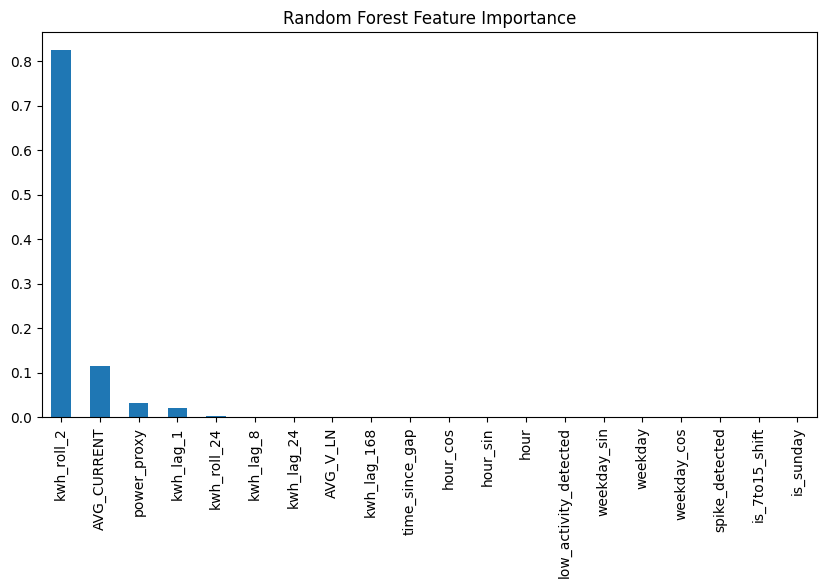

In [17]:
plt.figure(figsize=(7, 3))
feat_imp = pd.Series(rf_random.best_estimator_.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', title="Random Forest Feature Importance", figsize=(10,5))
plt.show()

In [18]:
# Compute residuals
residuals = y_test - y_test_pred

# Create DataFrame for Plotly
res_df = pd.DataFrame({
    "Predicted": y_test_pred,
    "Residuals": residuals
}, index=y_test.index)

# Plot
fig = px.scatter(
    res_df,
    x="Predicted",
    y="Residuals",
    title="Residuals vs Predicted",
    labels={
        "Predicted": "Predicted Energy",
        "Residuals": "Residual (Actual - Predicted)"
    },
    opacity=0.7
)

# Add horizontal zero line
fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.show()

In [19]:
# Convert to DataFrame
res_df = pd.DataFrame({
    "Residuals": residuals
})

# Plot interactive histogram
fig = px.histogram(
    res_df,
    x="Residuals",
    nbins=50,
    title="Residual Distribution",
    labels={"Residuals": "Residual (Actual - Predicted)"},
    opacity=0.75
)

# Optional: add mean & zero reference lines
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.add_vline(
    x=residuals.mean(),
    line_dash="dot",
    line_color="green",
    annotation_text="Mean",
    annotation_position="top"
)

fig.show()


In [20]:
# Create DataFrame
ap_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
}, index=y_test.index)

# Interactive scatter plot
fig = px.scatter(
    ap_df,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted",
    labels={
        "Actual": "Actual Value",
        "Predicted": "Predicted Value"
    },
    opacity=0.7
)

# Add perfect prediction line (y = x)
min_val = min(ap_df.min())
max_val = max(ap_df.max())
fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash", color="red"),
)

fig.show()

In [21]:
# Ensure data is aligned
ts_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
}, index=y_test.index).sort_index()

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Actual"],
    mode="lines",
    name="Actual",
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Predicted"],
    mode="lines",
    name="Predicted",
    line=dict(width=2, dash="dash"),
    opacity=0.85
))

fig.update_layout(
    title="Actual vs Predicted Energy Over Time",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white"
)

fig.show()

In [22]:
# -----------------------------
# 1. Identify last timestamp
# -----------------------------
last_time = rf_X.index.max()
print("Last timestamp:", last_time)

# -----------------------------
# 2. Create next day hourly timestamps
# -----------------------------
next_day_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

next_day_X = pd.DataFrame(index=next_day_times)
next_day_X["hour"] = next_day_X.index.hour
next_day_X["weekday"] = next_day_X.index.weekday

hour = next_day_X["hour"]
weekday = next_day_X["weekday"]

# -----------------------------
# 3. Prepare historical stats (PAST DATA ONLY)
# -----------------------------
hist_df = rf_X.loc[rf_X.index < next_day_times[0]].copy()
hist_df["hour"] = hist_df.index.hour
hist_df["weekday"] = hist_df.index.weekday

# Weekday + hour mean
weekday_hour_means = (
    hist_df
    .groupby(["weekday", "hour"])[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

# Hour-only fallback
hour_means = hist_df.groupby("hour")[["AVG_CURRENT", "AVG_V_LN"]].mean()

# -----------------------------
# 4. Populate AVG_CURRENT & AVG_V_LN (CORRECT WAY)
# -----------------------------
next_day_X = next_day_X.merge(
    weekday_hour_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Fallbacks
for col in ["AVG_CURRENT", "AVG_V_LN"]:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_means[col])
    )

next_day_X[["AVG_CURRENT", "AVG_V_LN"]] = (
    next_day_X[["AVG_CURRENT", "AVG_V_LN"]]
    .fillna(hist_df[["AVG_CURRENT", "AVG_V_LN"]].mean())
)

# -----------------------------
# 5. Power proxy
# -----------------------------
next_day_X["power_proxy"] = (
    next_day_X["AVG_CURRENT"] * next_day_X["AVG_V_LN"]
)

# -----------------------------
# 6. Cyclical time encoding
# -----------------------------
next_day_X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
next_day_X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
next_day_X["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
next_day_X["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

# -----------------------------
# 7. Lag features (target-based)
# -----------------------------
hist_df["kwh_lag_1"]   = y.shift(1)
hist_df["kwh_lag_8"]   = y.shift(8)
hist_df["kwh_lag_24"]  = y.shift(24)
hist_df["kwh_lag_168"] = y.shift(168)

lag_cols = ["kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168"]
weekday_hour_lag_means = (
    hist_df
    .groupby(["weekday", "hour"])[lag_cols]
    .mean()
)
hour_lag_means = (
    hist_df
    .groupby("hour")[lag_cols]
    .mean()
)

next_day_X = next_day_X.merge(
    weekday_hour_lag_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)
# Fallback
for col in lag_cols:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_lag_means[col])
    )

next_day_X[lag_cols] = next_day_X[lag_cols].fillna(
    hist_df[lag_cols].mean()
)

# -----------------------------
# 8. Rolling statistics
# -----------------------------
hist_df["kwh_roll_2"] = y.rolling(2).mean()
hist_df["kwh_roll_24"] = y.rolling(24).mean()

roll_cols = ["kwh_roll_2", "kwh_roll_24"]
weekday_hour_roll_means = (
    hist_df
    .groupby(["weekday", "hour"])[roll_cols]
    .mean()
)
hour_roll_means = (
    hist_df
    .groupby("hour")[roll_cols]
    .mean()
)

next_day_X = next_day_X.merge(
    weekday_hour_roll_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Fallback
for col in roll_cols:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_roll_means[col])
    )

next_day_X[roll_cols] = next_day_X[roll_cols].fillna(
    hist_df[roll_cols].mean()
)

# -----------------------------
# 9. Shift & calendar features
# -----------------------------
next_day_X["is_7to15_shift"] = ((hour >= 7) & (hour <= 15)).astype(int)
next_day_X["is_sunday"] = (weekday == 6).astype(int)

# -----------------------------
# 10. Gap & activity flags
# -----------------------------
next_day_X["time_since_gap"] = rf_X["time_since_gap"].iloc[-1] + 1
next_day_X["low_activity_detected"] = rf_X["low_activity_detected"].iloc[-1]
next_day_X["spike_detected"] = rf_X["spike_detected"].iloc[-1]

# -----------------------------
# 11. Align feature order
# -----------------------------
next_day_X = next_day_X[rf_feature_cols]

# -----------------------------
# 12. Predict (Random Forest)
# -----------------------------
next_day_pred = rf_random.predict(next_day_X)

# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df = pd.DataFrame(
    {"Predicted": next_day_pred},
    index=next_day_X.index
)

# -----------------------------
# 14. Plot
# -----------------------------
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines+markers",
    name="Predicted Next Day",
    line=dict(color="green", width=2)
))

fig.update_layout(
    title="Next Day Hourly Energy Prediction (Random Forest)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()


Last timestamp: 2025-12-29 08:00:00


### NEXT 7 DAYS (168 HOURS) FORECAST

In [23]:
# -----------------------------
# 1. Identify last timestamp
# -----------------------------
last_time = rf_X.index.max()
print("Last timestamp:", last_time)

# -----------------------------
# 2. Create next 7 days hourly timestamps
# -----------------------------
HORIZON = 24 * 7  # 168 hours

next_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=HORIZON,
    freq="h"
)

next_X = pd.DataFrame(index=next_times)
next_X["hour"] = next_X.index.hour
next_X["weekday"] = next_X.index.weekday

hour = next_X["hour"]
weekday = next_X["weekday"]

# -----------------------------
# 3. Prepare historical stats (PAST DATA ONLY)
# -----------------------------
hist_df = rf_X.loc[rf_X.index < next_times[0]].copy()
hist_df["hour"] = hist_df.index.hour
hist_df["weekday"] = hist_df.index.weekday

weekday_hour_means = (
    hist_df
    .groupby(["weekday", "hour"])[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

hour_means = (
    hist_df
    .groupby("hour")[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

# -----------------------------
# 4. Populate AVG_CURRENT & AVG_V_LN
# -----------------------------
next_X = next_X.merge(
    weekday_hour_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

for col in ["AVG_CURRENT", "AVG_V_LN"]:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_means[col])
    )

next_X[["AVG_CURRENT", "AVG_V_LN"]] = (
    next_X[["AVG_CURRENT", "AVG_V_LN"]]
    .fillna(hist_df[["AVG_CURRENT", "AVG_V_LN"]].mean())
)

# -----------------------------
# 5. Power proxy
# -----------------------------
next_X["power_proxy"] = (
    next_X["AVG_CURRENT"] * next_X["AVG_V_LN"]
)

# -----------------------------
# 6. Cyclical time encoding
# -----------------------------
next_X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
next_X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
next_X["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
next_X["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

# -----------------------------
# 7. Lag features (STATIC – LAST KNOWN)
# -----------------------------
hist_df["kwh_lag_1"]   = y.shift(1)
hist_df["kwh_lag_8"]   = y.shift(8)
hist_df["kwh_lag_24"]  = y.shift(24)
hist_df["kwh_lag_168"] = y.shift(168)

lag_cols  = ["kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168"]
weekday_hour_lag_means = (
    hist_df
    .groupby(["weekday", "hour"])[lag_cols]
    .mean()
)
hour_lag_means = (
    hist_df
    .groupby("hour")[lag_cols]
    .mean()
)

# Lag features
next_X = next_X.merge(
    weekday_hour_lag_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Lag fallbacks
for col in lag_cols:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_lag_means[col])
    )

next_X[lag_cols] = next_X[lag_cols].fillna(
    hist_df[lag_cols].mean()
)

# -----------------------------
# 8. Rolling statistics
# -----------------------------
hist_df["kwh_roll_2"]  = y.rolling(2).mean()
hist_df["kwh_roll_24"] = y.rolling(24).mean()

roll_cols = ["kwh_roll_2", "kwh_roll_24"]
weekday_hour_roll_means = (
    hist_df
    .groupby(["weekday", "hour"])[roll_cols]
    .mean()
)
hour_roll_means = (
    hist_df
    .groupby("hour")[roll_cols]
    .mean()
)

# Rolling features
next_X = next_X.merge(
    weekday_hour_roll_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Rolling fallbacks
for col in roll_cols:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_roll_means[col])
    )

next_X[roll_cols] = next_X[roll_cols].fillna(
    hist_df[roll_cols].mean()
)
# -----------------------------
# 9. Shift & calendar features
# -----------------------------
next_X["is_7to15_shift"] = ((hour >= 7) & (hour <= 15)).astype(int)
next_X["is_sunday"] = (weekday == 6).astype(int)

# -----------------------------
# 10. Gap & activity flags
# -----------------------------
next_X["time_since_gap"] = rf_X["time_since_gap"].iloc[-1] + 1
next_X["low_activity_detected"] = rf_X["low_activity_detected"].iloc[-1]
next_X["spike_detected"] = rf_X["spike_detected"].iloc[-1]

# -----------------------------
# 11. Align feature order
# -----------------------------
next_X = next_X[rf_feature_cols]

# -----------------------------
# 12. Predict (Random Forest)
# -----------------------------
next_pred = rf_random.predict(next_X)

# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df = pd.DataFrame(
    {"Predicted": next_pred},
    index=next_X.index
)


Last timestamp: 2025-12-29 08:00:00


In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines",
    name="Next 7 Days Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Next 7 Days Hourly Energy Forecast (Random Forest)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()

In [25]:
daily_forecast = (
    forecast_df
    .resample("D")
    .sum()
)

fig.add_trace(go.Bar(
    x=daily_forecast.index,
    y=daily_forecast["Predicted"],
    name="Daily Energy (kWh)",
    opacity=0.6
))